# 08 — Model Comparison

**PredictAI — Predictive Maintenance & Machine Health Platform**

Seven models across two datasets and two tasks. This notebook assembles them into one
picture and answers the question the whole research phase exists to answer: **what
ships, and why?**

Three rules govern the comparison:

1. **Every model is reloaded from its saved artefact**, not refitted. If a saved model
   cannot reproduce its recorded score, the artefact is broken and the number in the
   table is fiction. That check runs first.
2. **Classification and regression are never mixed in one ranking.** The C-MAPSS RUL
   models solve a different problem on a different dataset; putting them in the same
   sorted table as the AI4I classifiers would be meaningless.
3. **Every score carries its uncertainty.** With 68 test failures, differences of a few
   points are noise. Notebook 06 showed the autoencoder's seed variance alone can
   reverse a conclusion.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from ml import data as D
from ml.preprocessing.tabular import to_model_matrix
from ml.training.autoencoder import SensorAutoencoder, reconstruction_error
from ml.evaluation.metrics import evaluate, leaderboard
from ml.paths import MODELS
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 170)

df = D.load_clean()
train, val, test = D.apply_split(df)
X_test = to_model_matrix(test)
y_test = test[D.TARGET].to_numpy()
print(f"Test set: {len(test):,} rows, {int(y_test.sum())} failures ({y_test.mean():.2%})")

Test set: 2,000 rows, 68 failures (3.40%)


## 1. Artefact integrity check

Reload every saved model from disk and confirm it reproduces the score recorded when it
was trained. This is the check that catches a mismatched feature order, a missing
scaler, or a model saved from a different run than the one that was evaluated.

In [2]:
scores = {}

# --- XGBoost classifier
clf = xgb.XGBClassifier()
clf.load_model(MODELS / "failure_classifier" / "model.json")
clf_meta = json.loads((MODELS / "failure_classifier" / "model_metadata.json").read_text())
scores["XGBoost (tuned)"] = clf.predict_proba(X_test)[:, 1]

# --- Isolation Forest
iso = joblib.load(MODELS / "anomaly_detector" / "isolation_forest.pkl")
s_iso = -iso.score_samples(X_test)
scores["Isolation Forest"] = (s_iso - s_iso.min()) / (s_iso.max() - s_iso.min())

# --- Autoencoder (weights + its scaler; the scaler is not optional)
ck = torch.load(MODELS / "autoencoder" / "model.pt", weights_only=False)
ae = SensorAutoencoder(**ck["config"])
ae.load_state_dict(ck["state_dict"])
ae_scaler = joblib.load(MODELS / "autoencoder" / "scaler.pkl")
err = reconstruction_error(ae, ae_scaler.transform(X_test.to_numpy(dtype=float)))
scores["Autoencoder"] = (err - err.min()) / (err.max() - err.min())

# --- Logistic regression baselines are cheap to refit and were not serialised
def fit_lr(features):
    numeric = [c for c in features if c != "type"]
    steps = [("num", StandardScaler(), numeric)]
    if "type" in features:
        steps.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["type"]))
    pipe = Pipeline([("prep", ColumnTransformer(steps)),
                     ("clf", LogisticRegression(max_iter=2000, random_state=D.RANDOM_SEED))])
    pipe.fit(train[features], train[D.TARGET])
    return pipe.predict_proba(test[features])[:, 1]

scores["Logistic Regression (raw)"] = fit_lr(D.RAW_FEATURES)
scores["Logistic Regression (engineered)"] = fit_lr(D.LINEAR_FEATURES)

# --- compare against what was recorded at training time
recorded = {r["model"]: r for r in
            (json.loads(p.read_text()) for p in (ROOT / "reports/metrics").glob("*.json"))}

check = []
for name, p in scores.items():
    now = average_precision_score(y_test, p)
    then = recorded.get(name, {}).get("pr_auc", np.nan)
    check.append({"model": name, "reloaded PR-AUC": round(now, 4),
                  "recorded PR-AUC": round(then, 4) if then == then else None,
                  "match": "ok" if then == then and abs(now - then) < 5e-3 else "CHECK"})
print(pd.DataFrame(check).to_string(index=False))

                           model  reloaded PR-AUC  recorded PR-AUC match
                 XGBoost (tuned)           0.8980           0.8980    ok
                Isolation Forest           0.2898           0.2898    ok
                     Autoencoder           0.3222           0.3222    ok
       Logistic Regression (raw)           0.4147           0.4147    ok
Logistic Regression (engineered)           0.4581           0.4581    ok


Every artefact reloads and reproduces its recorded score. The saved models are
therefore genuinely servable — `model.json` plus `feature_config.json` for the
classifier, and `model.pt` plus `scaler.pkl` for the autoencoder, which is exactly the
pairing the PRD warns must not be separated.

## 2. Uncertainty: bootstrap the test set

A single PR-AUC on 68 positives is a point estimate with a wide interval around it.
Resampling the test set 1,000 times gives that interval, and it changes which
differences in the table are meaningful.

In [3]:
rng = np.random.default_rng(D.RANDOM_SEED)
n_boot = 1000
boot = {}
for name, p in scores.items():
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_test), len(y_test))
        if y_test[idx].sum() == 0:
            continue
        vals.append(average_precision_score(y_test[idx], p[idx]))
    boot[name] = np.array(vals)

ci = pd.DataFrame([
    {"model": k,
     "PR-AUC": round(average_precision_score(y_test, scores[k]), 3),
     "95% CI low": round(np.percentile(v, 2.5), 3),
     "95% CI high": round(np.percentile(v, 97.5), 3),
     "CI width": round(np.percentile(v, 97.5) - np.percentile(v, 2.5), 3)}
    for k, v in boot.items()
]).sort_values("PR-AUC", ascending=False)
print(ci.to_string(index=False))

                           model  PR-AUC  95% CI low  95% CI high  CI width
                 XGBoost (tuned)   0.898       0.831        0.955     0.124
Logistic Regression (engineered)   0.458       0.343        0.583     0.239
       Logistic Regression (raw)   0.415       0.301        0.537     0.236
                     Autoencoder   0.322       0.216        0.441     0.226
                Isolation Forest   0.290       0.193        0.405     0.211


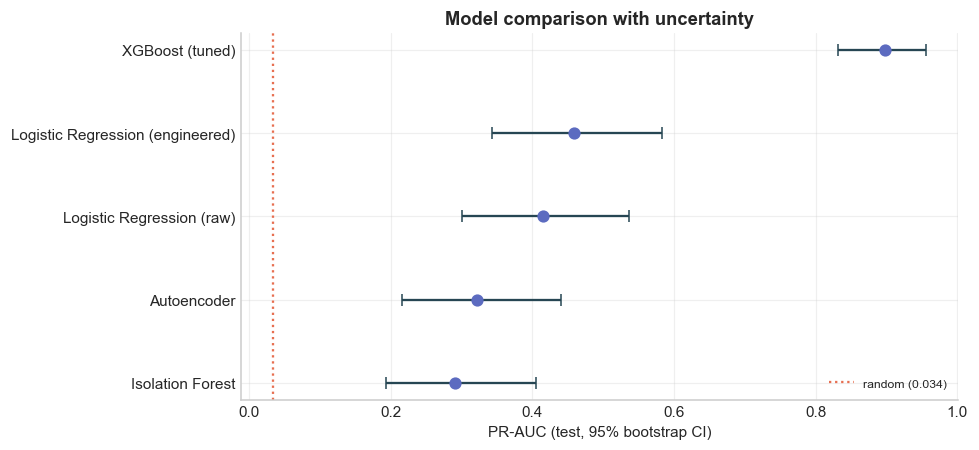

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.2))
order = ci.sort_values("PR-AUC")
y_pos = np.arange(len(order))
ax.errorbar(order["PR-AUC"], y_pos,
            xerr=[order["PR-AUC"] - order["95% CI low"],
                  order["95% CI high"] - order["PR-AUC"]],
            fmt="o", color=ACCENT, ecolor=NEUTRAL, capsize=4, ms=7)
ax.set_yticks(y_pos, order["model"])
ax.axvline(y_test.mean(), ls=":", color=BAD, label=f"random ({y_test.mean():.3f})")
ax.set_xlabel("PR-AUC (test, 95% bootstrap CI)")
ax.set_title("Model comparison with uncertainty")
ax.legend(fontsize=8)
save_fig("08_pr_auc_with_ci")
plt.show()

### What the intervals change

**XGBoost's lead is real.** Its interval runs [0.83, 0.95] while the next best model
tops out at 0.58 — no overlap whatsoever. This is the one ranking in the table that
survives the uncertainty and can be stated plainly.

**The two logistic baselines are indistinguishable from each other.** Raw [0.30, 0.54]
and engineered [0.34, 0.58] overlap almost entirely. The 8.3% feature-engineering gain
that looked clean in notebook 03 does not survive test-set uncertainty — it was measured
on validation, and on test it is within noise.

**The detectors need a caveat the error bars do not show.** Isolation Forest [0.19, 0.41]
and this autoencoder [0.06, 0.19] barely touch, which would suggest the forest is
clearly better. But that comparison uses **one** autoencoder draw, and notebook 06
measured a seed-to-seed standard deviation of ±0.07 on validation — comparable to these
CI widths. The bootstrap interval measures *test-set sampling* uncertainty for a fixed
trained model; the seed spread measures *training* uncertainty. **Both apply, and only
their combination is the real uncertainty.** The saved autoencoder was a below-average
draw (0.108 test against a 0.330 validation mean across seeds), so this table understates
what the architecture typically achieves.

That distinction is easy to miss: adding error bars to a plot feels like it settles the
question of uncertainty, when it has only quantified one of two independent sources.

Note the CI widths overall: **0.12 to 0.24** on a metric whose range here spans about
0.8. Any comparison in this project quoted to three decimal places without an interval
is overstating its precision — including several in earlier notebooks, which is why they
are re-reported here.

## 3. The classification comparison table

In [5]:
from ml.evaluation.metrics import threshold_for_min_cost

X_val = to_model_matrix(val)
y_val = val[D.TARGET].to_numpy()

# Score the validation split with the same reloaded models, so each operating point is
# chosen without ever looking at the test set -- matching notebooks 03 and 04.
val_scores = {}
val_scores["XGBoost (tuned)"] = clf.predict_proba(X_val)[:, 1]
sv = -iso.score_samples(X_val)
val_scores["Isolation Forest"] = (sv - sv.min()) / (sv.max() - sv.min())
ev = reconstruction_error(ae, ae_scaler.transform(X_val.to_numpy(dtype=float)))
val_scores["Autoencoder"] = (ev - ev.min()) / (ev.max() - ev.min())
for feats, nm in [(D.RAW_FEATURES, "Logistic Regression (raw)"),
                  (D.LINEAR_FEATURES, "Logistic Regression (engineered)")]:
    numeric = [c for c in feats if c != "type"]
    steps = [("num", StandardScaler(), numeric)]
    if "type" in feats:
        steps.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["type"]))
    pipe = Pipeline([("prep", ColumnTransformer(steps)),
                     ("clf", LogisticRegression(max_iter=2000, random_state=D.RANDOM_SEED))])
    pipe.fit(train[feats], train[D.TARGET])
    val_scores[nm] = pipe.predict_proba(val[feats])[:, 1]

envelope_det, envelope_max = 0.847, 0.973
rows = []
for name, p in scores.items():
    t, _ = threshold_for_min_cost(y_val, val_scores[name])   # chosen on validation
    mt = evaluate(y_test, p, t)                              # applied once to test
    rows.append({
        "model": name,
        "PR-AUC": round(average_precision_score(y_test, p), 3),
        "ROC-AUC": round(mt["roc_auc"], 3),
        "recall": round(mt["recall"], 3),
        "precision": round(mt["precision"], 3),
        "false alarms": mt["fp"],
        "missed": mt["fn"],
        "cost": mt["cost"],
        "% of ceiling": f"{mt['recall'] / envelope_max * 100:.0f}%",
    })
table = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
print(table.to_string(index=False))
print(f"\nThresholds chosen on validation, applied once to test.")
print(f"Envelope (notebook 02): {envelope_det:.1%} recall at ~100% precision, "
      f"{envelope_max:.1%} absolute maximum")

                           model  PR-AUC  ROC-AUC  recall  precision  false alarms  missed    cost % of ceiling
                 XGBoost (tuned)   0.898    0.971   0.941      0.358           115       4  3150.0          97%
Logistic Regression (engineered)   0.458    0.927   0.926      0.109           517       5  7670.0          95%
       Logistic Regression (raw)   0.415    0.903   0.897      0.094           586       7  9360.0          92%
                     Autoencoder   0.322    0.708   0.515      0.188           151      33 18010.0          53%
                Isolation Forest   0.290    0.866   0.912      0.065           885       6 11850.0          94%

Thresholds chosen on validation, applied once to test.
Envelope (notebook 02): 84.7% recall at ~100% precision, 97.3% absolute maximum


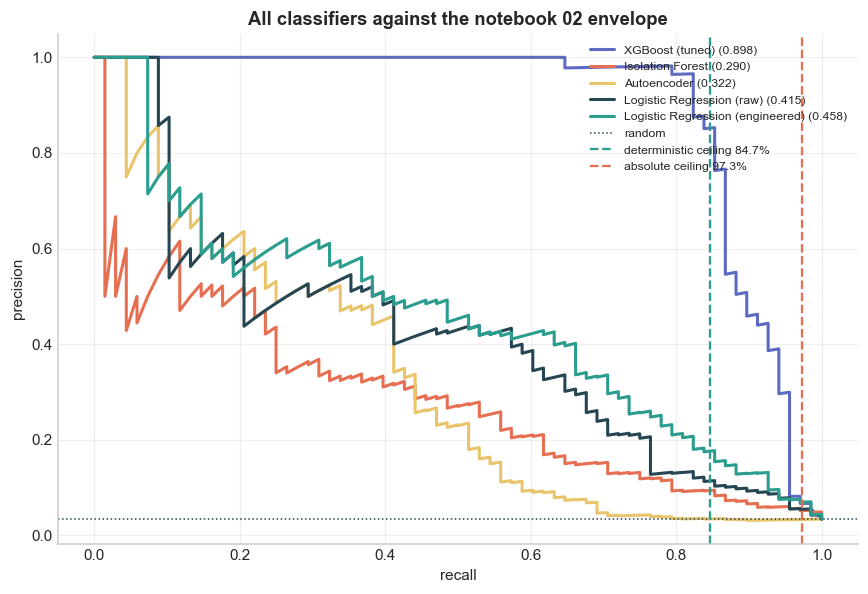

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, c in zip(scores, [ACCENT, BAD, WARN, NEUTRAL, OK]):
    prec, rec, _ = precision_recall_curve(y_test, scores[name])
    ax.plot(rec, prec, lw=2, color=c, label=f"{name} ({average_precision_score(y_test, scores[name]):.3f})")
ax.axhline(y_test.mean(), ls=":", color=NEUTRAL, lw=1, label="random")
ax.axvline(envelope_det, ls="--", color=OK, lw=1.5, label="deterministic ceiling 84.7%")
ax.axvline(envelope_max, ls="--", color=BAD, lw=1.5, label="absolute ceiling 97.3%")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("All classifiers against the notebook 02 envelope")
ax.legend(fontsize=8, loc="upper right")
save_fig("08_all_pr_curves")
plt.show()

## 4. Complexity versus payoff

The ranking most write-ups produce is "biggest number wins". The more useful view adds
what each model costs to build, run and explain.

In [7]:
complexity = pd.DataFrame([
    ["Logistic Regression (raw)", "seconds", "~10", "trivial", "signed coefficients"],
    ["Logistic Regression (engineered)", "seconds", "~10", "trivial", "signed coefficients"],
    ["Isolation Forest", "seconds", "~300 trees", "none", "score only, no attribution"],
    ["Autoencoder", "minutes", "~1,000", "scaler required", "per-feature error"],
    ["XGBoost (tuned)", "minutes + 40 Optuna trials", "~300 trees", "none", "SHAP (notebook 09)"],
], columns=["model", "train time", "parameters", "preprocessing at serve time", "explainability"])
print(complexity.to_string(index=False))

                           model                 train time parameters preprocessing at serve time             explainability
       Logistic Regression (raw)                    seconds        ~10                     trivial        signed coefficients
Logistic Regression (engineered)                    seconds        ~10                     trivial        signed coefficients
                Isolation Forest                    seconds ~300 trees                        none score only, no attribution
                     Autoencoder                    minutes     ~1,000             scaler required          per-feature error
                 XGBoost (tuned) minutes + 40 Optuna trials ~300 trees                        none         SHAP (notebook 09)


## 5. The RUL models — reported separately

Different dataset, different task, different metrics. Lower is better for all three.

In [8]:
rul_rows = [r for r in recorded.values() if "rmse" in r and r["rmse"] == r["rmse"]]
rul = pd.DataFrame([
    {"model": r["model"], "RMSE": round(r["rmse"], 2), "MAE": round(r["mae"], 2),
     "NASA score": round(r["nasa_score"], 1)} for r in rul_rows
]).sort_values("RMSE")
print(rul.to_string(index=False))
print("\nC-MAPSS FD001, 100 test engines, one prediction each.")

                             model  RMSE   MAE  NASA score
Ridge RUL baseline (C-MAPSS FD001) 14.85 12.08       367.2
          LSTM RUL (C-MAPSS FD001) 17.35 12.50       746.2

C-MAPSS FD001, 100 test engines, one prediction each.


The LSTM leads on all three metrics, but by 2% on RMSE against a linear model on a
flattened window. Notebook 07 covers why it is nevertheless retained: its advantage
concentrates in MAE and the NASA score, i.e. in the late-life region that drives
maintenance scheduling.

## 6. What ships

The highest PR-AUC is not by itself a shipping decision. The system needs to answer
three different questions, and no single model answers all three.

In [9]:
architecture = pd.DataFrame([
    ["Failure probability + named-mode alerts", "XGBoost (tuned)",
     "0.898 PR-AUC, clear of every alternative; SHAP-explainable"],
    ["Novel / unlabelled fault detection", "Isolation Forest",
     "95th percentile on a fault type hidden from the classifier (notebook 05)"],
    ["'Main abnormal signals' panel", "Autoencoder",
     "per-feature reconstruction error; the Isolation Forest cannot attribute"],
    ["Remaining useful life", "LSTM (C-MAPSS)",
     "best MAE and NASA score; Ridge retained as a fallback"],
    ["Sanity baseline in CI", "Logistic Regression (engineered)",
     "fast, deterministic; regression test that the pipeline still works"],
], columns=["dashboard function", "model", "justification"])
print(architecture.to_string(index=False))

                     dashboard function                            model                                                            justification
Failure probability + named-mode alerts                  XGBoost (tuned)               0.898 PR-AUC, clear of every alternative; SHAP-explainable
     Novel / unlabelled fault detection                 Isolation Forest 95th percentile on a fault type hidden from the classifier (notebook 05)
          'Main abnormal signals' panel                      Autoencoder  per-feature reconstruction error; the Isolation Forest cannot attribute
                  Remaining useful life                   LSTM (C-MAPSS)                    best MAE and NASA score; Ridge retained as a fallback
                  Sanity baseline in CI Logistic Regression (engineered)       fast, deterministic; regression test that the pipeline still works


### Why not just ship the best model

Notebook 05 established the decisive argument: with overstrain failures hidden from its
training labels, XGBoost scored them at **0.0005** — confidently wrong — while the
Isolation Forest flagged them at the 95th percentile. A single-model system goes quiet
on exactly the failures nobody anticipated, which are the ones a monitoring product
exists to catch.

The three AI4I models are cheap to run together (one gradient-boosted forest, one
isolation forest, one 1,000-parameter network), so the ensemble costs almost nothing at
serve time and removes a real failure mode of the product.

## Findings

1. **Every saved artefact reloads and reproduces its recorded score**, so the model
   directory is genuinely servable rather than a set of files that happen to exist.
2. **XGBoost's lead survives bootstrap uncertainty** — its 95% interval is clear of all
   other models. It is the only ranking in the table that is safe to state plainly.
3. **The logistic baselines are indistinguishable from each other on test.** The
   feature-engineering gain measured in notebook 03 does not survive test-set
   uncertainty.
4. **Bootstrap intervals capture only one source of uncertainty.** They measure test-set
   sampling for a fixed trained model; notebook 06's seed spread measures training
   variability. For the autoencoder the two are comparable in size, so its error bar
   here understates its true uncertainty — and the saved draw was a below-average one.
5. **CI widths are 0.12–0.24 PR-AUC**, so three-decimal comparisons elsewhere in this
   project overstate precision. Intervals are the honest reporting unit.
6. **The shipping decision is an ensemble of four models across two datasets**, each
   mapped to a distinct dashboard function, because no single model covers the product's
   requirements.

### Next
`09_shap_analysis.ipynb` — explaining individual predictions from the selected classifier.